# Transformer 从零实现

本 notebook 从零实现 Transformer 模型，不依赖 d2l 库的模型组件（仅使用其数据加载和训练辅助函数）。

In [1]:
# 安装 d2l 教学库（用于数据加载和辅助工具）
%pip install d2l --no-deps --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 4.4 MB/s eta 0:00:00


In [2]:
import math
import torch
import pandas as pd
from torch import nn
from d2l import torch as d2l

## 1. 基础工具函数

In [3]:
def sequence_mask(X, valid_len, value=0):
    """序列掩码函数
    
    将序列中超出有效长度的位置屏蔽为指定值。
    
    Args:
        X: 形状 (batch_size, num_steps) 的张量
        valid_len: 形状 (batch_size,) 的有效长度
        value: 用于填充屏蔽位置的值
    
    Returns:
        掩码后的张量
    """
    maxlen = X.size(1)
    mask = torch.arange(maxlen, dtype=torch.float32, device=X.device)[None, :] < valid_len[:, None]
    X[~mask] = value
    return X


def masked_softmax(X, valid_lens):
    """带掩码的 softmax 操作
    
    在最后一个轴上执行 softmax，对指定位置进行掩码。
    
    Args:
        X: 形状 (batch_size, num_queries, num_keys) 的分数张量
        valid_lens: 形状 (batch_size,) 或 (batch_size, num_queries) 的有效长度
    
    Returns:
        归一化的注意力权重
    """
    if valid_lens is None:
        return nn.functional.softmax(X, dim=-1)
    else:
        shape = X.shape
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens, shape[1])
        else:
            valid_lens = valid_lens.reshape(-1)
        # 在最后一个轴上，将屏蔽元素替换为一个非常大的负值
        X = sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value=-1e6)
        return nn.functional.softmax(X.reshape(shape), dim=-1)

## 2. 多头注意力机制

In [4]:
class DotProductAttention(nn.Module):
    """缩放点积注意力
    
    计算: softmax(QK^T / sqrt(d)) * V
    """
    def __init__(self, dropout, **kwargs):
        super(DotProductAttention, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)
        # 存储注意力权重用于可视化
        self.attention_weights = None

    def forward(self, queries, keys, values, valid_lens=None):
        """前向传播
        
        Args:
            queries: (batch_size*num_heads, num_queries, d)
            keys: (batch_size*num_heads, num_keys, d)
            values: (batch_size*num_heads, num_keys, d)
            valid_lens: 有效长度
        
        Returns:
            注意力加权后的值
        """
        d = queries.shape[-1]
        scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(d)
        self.attention_weights = masked_softmax(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)

In [5]:
def transpose_qkv(X, num_heads):
    """为多头注意力并行计算而变换形状
    
    输入: (batch_size, num_queries, num_hiddens)
    输出: (batch_size * num_heads, num_queries, num_hiddens / num_heads)
    """
    X = X.reshape(X.shape[0], X.shape[1], num_heads, -1)
    X = X.permute(0, 2, 1, 3)
    return X.reshape(-1, X.shape[2], X.shape[3])


def transpose_output(X, num_heads):
    """逆转 transpose_qkv 的操作
    
    输入: (batch_size * num_heads, num_queries, num_hiddens / num_heads)
    输出: (batch_size, num_queries, num_hiddens)
    """
    X = X.reshape(-1, num_heads, X.shape[1], X.shape[2])
    X = X.permute(0, 2, 1, 3)
    return X.reshape(X.shape[0], X.shape[1], -1)

In [6]:
class MultiHeadAttention(nn.Module):
    """多头注意力模块
    
    将输入投影到多个子空间，在每个子空间独立计算注意力。
    支持不同的 query_size, key_size, value_size。
    """
    def __init__(self, key_size, query_size, value_size, num_hiddens, 
                 num_heads, dropout, bias=False, **kwargs):
        super(MultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.attention = DotProductAttention(dropout)
        # 使用独立的输入维度：query_size, key_size, value_size
        self.W_q = nn.Linear(query_size, num_hiddens, bias=bias)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=bias)
        self.W_v = nn.Linear(value_size, num_hiddens, bias=bias)
        self.W_o = nn.Linear(num_hiddens, num_hiddens, bias=bias)

    def forward(self, queries, keys, values, valid_lens=None):
        """前向传播
        
        Args:
            queries: (batch_size, num_queries, query_size)
            keys: (batch_size, num_keys, key_size)
            values: (batch_size, num_keys, value_size)
            valid_lens: 有效长度
        
        Returns:
            多头注意力输出
        """
        # 线性投影 + 形状变换
        queries = transpose_qkv(self.W_q(queries), self.num_heads)
        keys = transpose_qkv(self.W_k(keys), self.num_heads)
        values = transpose_qkv(self.W_v(values), self.num_heads)
        
        # 处理有效长度
        if valid_lens is not None:
            valid_lens = torch.repeat_interleave(valid_lens, repeats=self.num_heads, dim=0)
        
        # 计算注意力
        output = self.attention(queries, keys, values, valid_lens)
        
        # 逆变换拼接多头结果
        output_concat = transpose_output(output, self.num_heads)
        return self.W_o(output_concat)

## 3. Transformer 核心组件

In [7]:
class PositionalEncoding(nn.Module):
    """位置编码
    
    使用正弦和余弦函数为序列中的每个位置生成编码。
    """
    def __init__(self, num_hiddens, dropout, max_len=1000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(dropout)
        # 创建位置编码矩阵
        self.P = torch.zeros((1, max_len, num_hiddens))
        X = torch.arange(max_len, dtype=torch.float32).reshape(
            -1, 1) / torch.pow(10000, torch.arange(
            0, num_hiddens, 2, dtype=torch.float32) / num_hiddens)
        self.P[:, :, 0::2] = torch.sin(X)
        self.P[:, :, 1::2] = torch.cos(X)

    def forward(self, X):
        """添加位置编码
        
        Args:
            X: (batch_size, num_steps, num_hiddens)
        
        Returns:
            添加位置编码后的 X
        """
        X = X + self.P[:, :X.shape[1], :].to(X.device)
        return self.dropout(X)

In [8]:
class PositionWiseFFN(nn.Module):
    """逐位置前馈网络
    
    对序列中每个位置独立地做相同的两层全连接变换。
    FFN(x) = max(0, xW1 + b1)W2 + b2
    """
    def __init__(self, ffn_num_input, ffn_num_hiddens, ffn_num_outputs, **kwargs):
        super(PositionWiseFFN, self).__init__(**kwargs)
        self.dense1 = nn.Linear(ffn_num_input, ffn_num_hiddens)
        self.relu = nn.ReLU()
        self.dense2 = nn.Linear(ffn_num_hiddens, ffn_num_outputs)

    def forward(self, X):
        return self.dense2(self.relu(self.dense1(X)))

In [9]:
class AddNorm(nn.Module):
    """残差连接 + 层归一化
    
    结构: LayerNorm(X + Dropout(Sublayer(X)))
    """
    def __init__(self, normalized_shape, dropout, **kwargs):
        super(AddNorm, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(normalized_shape)

    def forward(self, X, Y):
        """残差连接后层归一化
        
        Args:
            X: 原始输入（用于残差连接）
            Y: 子层输出
        
        Returns:
            LayerNorm(X + Dropout(Y))
        """
        return self.ln(self.dropout(Y) + X)

## 4. Transformer 编码器

In [10]:
class EncoderBlock(nn.Module):
    """Transformer 编码器块
    
    包含:
    1. 多头自注意力
    2. AddNorm
    3. PositionWiseFFN
    4. AddNorm
    """
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
                 dropout, use_bias=False, **kwargs):
        super(EncoderBlock, self).__init__(**kwargs)
        # 传递 key_size, query_size, value_size 给 MultiHeadAttention
        self.attention = MultiHeadAttention(
            key_size, query_size, value_size, num_hiddens, num_heads, dropout, use_bias)
        self.addnorm1 = AddNorm(norm_shape, dropout)
        self.ffn = PositionWiseFFN(ffn_num_input, ffn_num_hiddens, num_hiddens)
        self.addnorm2 = AddNorm(norm_shape, dropout)

    def forward(self, X, valid_lens):
        """前向传播
        
        Args:
            X: (batch_size, num_steps, num_hiddens)
            valid_lens: 有效序列长度
        
        Returns:
            编码器块输出
        """
        Y = self.addnorm1(X, self.attention(X, X, X, valid_lens))
        return self.addnorm2(Y, self.ffn(Y))

In [11]:
class Encoder(nn.Module):
    """编码器基类
    
    定义编码器接口。
    """
    def __init__(self):
        super(Encoder, self).__init__()

    def forward(self, X, *args):
        raise NotImplementedError

In [12]:
class TransformerEncoder(Encoder):
    """Transformer 编码器
    
    由 num_layers 个 EncoderBlock 堆叠而成。
    """
    def __init__(self, vocab_size, key_size, query_size, value_size,
                 num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens,
                 num_heads, num_layers, dropout, use_bias=False, **kwargs):
        super(TransformerEncoder, self).__init__(**kwargs)
        self.num_hiddens = num_hiddens
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_layers):
            self.blks.add_module("block" + str(i),
                EncoderBlock(key_size, query_size, value_size, num_hiddens,
                             norm_shape, ffn_num_input, ffn_num_hiddens,
                             num_heads, dropout, use_bias))

    def forward(self, X, valid_lens, *args):
        """前向传播
        
        Args:
            X: (batch_size, num_steps) 的 token id 序列
            valid_lens: 有效序列长度
        
        Returns:
            编码输出 (batch_size, num_steps, num_hiddens)
        """
        _ = args
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))
        self.attention_weights = [None] * len(self.blks)
        for i, blk in enumerate(self.blks):
            X = blk(X, valid_lens)
            self.attention_weights[i] = blk.attention.attention.attention_weights
        return X

## 5. Transformer 解码器

In [13]:
class Decoder(nn.Module):
    """解码器基类
    
    定义解码器接口。
    """
    def __init__(self):
        super(Decoder, self).__init__()

    def init_state(self, enc_outputs, *args):
        raise NotImplementedError

    def forward(self, X, state):
        raise NotImplementedError

In [14]:
class AttentionDecoder(Decoder):
    """带注意力的解码器基类
    
    定义注意力解码器接口。
    """
    def __init__(self):
        super(AttentionDecoder, self).__init__()

    @property
    def attention_weights(self):
        raise NotImplementedError

In [15]:
class DecoderBlock(nn.Module):
    """Transformer 解码器块
    
    包含三个子层:
    1. 掩码多头自注意力（训练时使用因果掩码）
    2. 编码器-解码器交叉注意力
    3. 前馈网络
    每个子层后接 AddNorm。
    """
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
                 dropout, i, **kwargs):
        super(DecoderBlock, self).__init__(**kwargs)
        self.i = i  # 层索引，用于缓存管理
        # 传递 key_size, query_size, value_size 给 MultiHeadAttention
        self.attention1 = MultiHeadAttention(
            key_size, query_size, value_size, num_hiddens, num_heads, dropout)
        self.addnorm1 = AddNorm(norm_shape, dropout)
        self.attention2 = MultiHeadAttention(
            key_size, query_size, value_size, num_hiddens, num_heads, dropout)
        self.addnorm2 = AddNorm(norm_shape, dropout)
        self.ffn = PositionWiseFFN(ffn_num_input, ffn_num_hiddens, num_hiddens)
        self.addnorm3 = AddNorm(norm_shape, dropout)

    def forward(self, X, state):
        """前向传播
        
        Args:
            X: 解码器输入 (batch_size, num_steps, num_hiddens)
            state: [enc_outputs, enc_valid_lens, [key_cache_per_layer]]
        
        Returns:
            解码器块输出, 更新后的 state
        """
        enc_outputs, enc_valid_lens = state[0], state[1]
        
        # 训练阶段：使用当前序列的完整输入
        # 预测阶段：使用缓存的历史 key/value
        if state[2][self.i] is None:
            key_values = X
        else:
            key_values = torch.cat((state[2][self.i], X), axis=1)
        state[2][self.i] = key_values
        
        # 训练时构造因果掩码
        if self.training:
            batch_size, num_steps, _ = X.shape
            dec_valid_lens = torch.arange(
                1, num_steps + 1, device=X.device).repeat(batch_size, 1)
        else:
            dec_valid_lens = None
        
        # 第一子层：掩码自注意力
        X2 = self.attention1(X, key_values, key_values, dec_valid_lens)
        Y = self.addnorm1(X, X2)
        
        # 第二子层：编码器-解码器交叉注意力
        Y2 = self.attention2(Y, enc_outputs, enc_outputs, enc_valid_lens)
        Z = self.addnorm2(Y, Y2)
        
        # 第三子层：FFN + AddNorm
        return self.addnorm3(Z, self.ffn(Z)), state

In [16]:
class TransformerDecoder(AttentionDecoder):
    """Transformer 解码器
    
    由 num_layers 个 DecoderBlock 堆叠而成。
    """
    def __init__(self, vocab_size, key_size, query_size, value_size,
                 num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens,
                 num_heads, num_layers, dropout, **kwargs):
        super(TransformerDecoder, self).__init__(**kwargs)
        self.num_hiddens = num_hiddens
        self.num_layers = num_layers
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_layers):
            self.blks.add_module("block" + str(i),
                DecoderBlock(key_size, query_size, value_size, num_hiddens,
                             norm_shape, ffn_num_input, ffn_num_hiddens,
                             num_heads, dropout, i))
        self.dense = nn.Linear(num_hiddens, vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens, *args):
        """初始化解码器状态
        
        Args:
            enc_outputs: 编码器输出
            enc_valid_lens: 源序列有效长度
        
        Returns:
            state 列表
        """
        return [enc_outputs, enc_valid_lens, [None] * self.num_layers]

    def forward(self, X, state):
        """前向传播
        
        Args:
            X: (batch_size, num_steps) 的 token id 序列
            state: 解码器状态
        
        Returns:
            输出 logits (batch_size, num_steps, vocab_size), state
        """
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))
        self._attention_weights = [[None] * len(self.blks) for _ in range(2)]
        for i, blk in enumerate(self.blks):
            X, state = blk(X, state)
            self._attention_weights[0][i] = blk.attention1.attention.attention_weights
            self._attention_weights[1][i] = blk.attention2.attention.attention_weights
        return self.dense(X), state

    @property
    def attention_weights(self):
        return self._attention_weights

## 6. Encoder-Decoder 模型

In [17]:
class EncoderDecoder(nn.Module):
    """编码器-解码器架构基类
    
    将编码器和解码器组合成完整模型。
    """
    def __init__(self, encoder, decoder):
        super(EncoderDecoder, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, enc_X, dec_X, *args):
        """前向传播
        
        Args:
            enc_X: 源序列 (batch_size, num_steps)
            dec_X: 目标序列 (batch_size, num_steps)
            *args: 额外参数（如 valid_lens）
        
        Returns:
            解码器输出 logits
        """
        enc_all_outputs = self.encoder(enc_X, *args)
        dec_state = self.decoder.init_state(enc_all_outputs, *args)
        return self.decoder(dec_X, dec_state)[0]

## 7. 训练函数

In [18]:
def train_seq2seq(net, data_iter, lr, num_epochs, tgt_vocab, device):
    """训练序列到序列模型
    
    Args:
        net: EncoderDecoder 模型
        data_iter: 数据迭代器
        lr: 学习率
        num_epochs: 训练轮数
        tgt_vocab: 目标语言词表
        device: 计算设备
    """
    def xavier_init_weights(m):
        if type(m) == nn.Linear:
            nn.init.xavier_uniform_(m.weight)
        if type(m) == nn.GRU:
            for param in m._flat_weights_names:
                if "weight" in param:
                    nn.init.xavier_uniform_(m._parameters[param])

    net.apply(xavier_init_weights)
    net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    loss = d2l.MaskedSoftmaxCELoss()
    net.train()
    animator = d2l.Animator(xlabel='epoch', ylabel='loss', xlim=[10, num_epochs])
    
    for epoch in range(num_epochs):
        timer = d2l.Timer()
        metric = d2l.Accumulator(2)
        
        for batch in data_iter:
            optimizer.zero_grad()
            X, X_valid_len, Y, Y_valid_len = [x.to(device) for x in batch]
            
            bos = torch.tensor([tgt_vocab['<bos>']] * Y.shape[0],
                               device=device).reshape(-1, 1)
            dec_input = torch.cat([bos, Y[:, :-1]], 1)
            
            Y_hat = net(X, dec_input, X_valid_len)
            
            if isinstance(Y_hat, (tuple, list)):
                Y_hat = Y_hat[0]
            
            l = loss(Y_hat, Y, Y_valid_len)
            l.sum().backward()
            d2l.grad_clipping(net, 1)
            num_tokens = Y_valid_len.sum()
            optimizer.step()
            
            with torch.no_grad():
                metric.add(l.sum(), num_tokens)
        
        if (epoch + 1) % 10 == 0:
            animator.add(epoch + 1, (metric[0] / metric[1],))
    
    print(f'loss {metric[0] / metric[1]:.3f}, {metric[1] / timer.stop():.1f} '
          f'tokens/sec on {str(device)}')

## 8. 模型训练

loss 0.033, 5162.9 tokens/sec on cpu


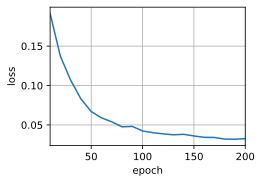

In [19]:
# ===== 超参数配置 =====
num_hiddens, num_layers, dropout, batch_size, num_steps = 32, 2, 0.1, 64, 10
lr, num_epochs, device = 0.005, 200, d2l.try_gpu()
ffn_num_input, ffn_num_hiddens, num_heads = 32, 64, 4
key_size, query_size, value_size = 32, 32, 32
norm_shape = [32]

# 加载英法翻译数据
train_iter, src_vocab, tgt_vocab = d2l.load_data_nmt(batch_size, num_steps)

# 构建 Transformer 编码器
encoder = TransformerEncoder(
    len(src_vocab), key_size, query_size, value_size, num_hiddens,
    norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
    num_layers, dropout)

# 构建 Transformer 解码器
decoder = TransformerDecoder(
    len(tgt_vocab), key_size, query_size, value_size, num_hiddens,
    norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
    num_layers, dropout)

# 组装成完整的模型
net = EncoderDecoder(encoder, decoder)

# 开始训练
train_seq2seq(net, train_iter, lr, num_epochs, tgt_vocab, device)

## 9. 翻译与 BLEU 评估

In [20]:
# ===== 用训练好的模型翻译并计算 BLEU =====
engs = ['go .', "i lost .", 'he\'s calm .', 'i\'m home .']
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']

for eng, fra in zip(engs, fras):
    translation, dec_attention_weight_seq = d2l.predict_seq2seq(
        net, eng, src_vocab, tgt_vocab, num_steps, device, True)
    print(f'{eng} => {translation}, '
          f'bleu {d2l.bleu(translation, fra, k=2):.3f}')

go . => va le <unk> ., bleu 0.000
i lost . => j'ai perdu ., bleu 1.000
he's calm . => il est mouillé ., bleu 0.658
i'm home . => je suis chez moi ., bleu 1.000


## 10. 注意力权重可视化

In [21]:
# 整理编码器各层各头的注意力权重
enc_attention_weights = torch.cat(net.encoder.attention_weights, 0).reshape(
    (num_layers, num_heads, -1, num_steps))
enc_attention_weights.shape

torch.Size([2, 4, 10, 10])

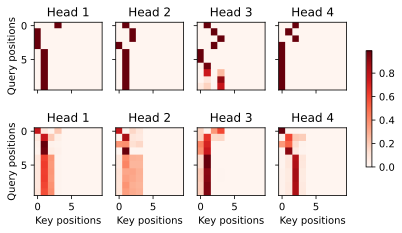

In [22]:
# 可视化编码器注意力热力图
d2l.show_heatmaps(
    enc_attention_weights.cpu(),
    xlabel='Key positions',
    ylabel='Query positions',
    titles=['Head %d' % i for i in range(1, 5)],
    figsize=(7, 3.5))

In [23]:
# ===== 整理解码器注意力权重 =====
dec_attention_weights_2d = [head[0].tolist()
                            for step in dec_attention_weight_seq
                            for attn in step for blk in attn for head in blk]

dec_attention_weights_filled = torch.tensor(
    pd.DataFrame(dec_attention_weights_2d).fillna(0.0).values)

dec_attention_weights = dec_attention_weights_filled.reshape(
    (-1, 2, num_layers, num_heads, num_steps))

dec_self_attention_weights, dec_inter_attention_weights = \
    dec_attention_weights.permute(1, 2, 3, 0, 4)
dec_self_attention_weights.shape, dec_inter_attention_weights.shape

(torch.Size([2, 4, 6, 10]), torch.Size([2, 4, 6, 10]))

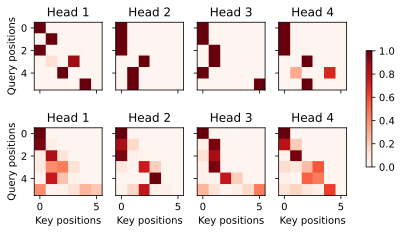

In [24]:
# 可视化解码器自注意力权重
d2l.show_heatmaps(
    dec_self_attention_weights[:, :, :, :len(translation.split()) + 1],
    xlabel='Key positions', ylabel='Query positions',
    titles=['Head %d' % i for i in range(1, 5)], figsize=(7, 3.5))

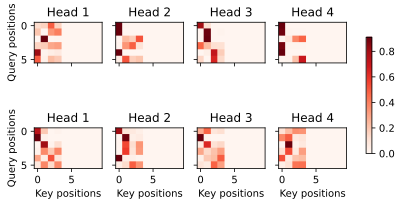

In [25]:
# 可视化解码器与编码器的交叉注意力权重
d2l.show_heatmaps(
    dec_inter_attention_weights,
    xlabel='Key positions',
    ylabel='Query positions',
    titles=['Head %d' % i for i in range(1, 5)],
    figsize=(7, 3.5))